# Лабораторная работа №5-6

## Вспомогательные статистические модели анализа временных рядов (модель Хольта-Винтерса и модель предсказания волатильности GARCH)

### Задание
- Продолжите работу над данными из лабораторной работы №2: загрузите в рабочую область предобработанные обучающие и тестовые данные о солнечной активности.
- Выполните исследование данных (тип тренда и сезонности, можно ссылаться на STL-декомпозицию) и определите параметры для модели ExponentialSmoothing из библиотеки statsmodels. Выполните обучение модели. Визуализируйте прогноз.
- Вычислите квадраты остатков (разниц между предсказанными значениями и истинными) и визуализируйте график их автокорреляции (plot_acf). Проанализируйте полученный график на предмет наличия зависимостей в ошибках.
- Постройте модель GARCH(1,1) и визуализируйте результат предсказания волатильности ряда на тестовой выборке.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.metrics import mean_absolute_error, mean_squared_error

from arch import arch_model

## Загрузка данных

Загружаем предобработанные `train` и `test` из лабораторной работы №2.
В столбце `Sunspots` после интерполяции встречаются два отрицательных значения, поэтому перед моделированием ограничим ряд снизу нулем.

In [4]:
train_path = '../lab_2/sunspots_train_preprocessed.csv'
test_path = '../lab_2/sunspots_test_preprocessed.csv'

train = pd.read_csv(train_path, parse_dates=['Month'])
test = pd.read_csv(test_path, parse_dates=['Month'])

negative_before_clip = int((train['Sunspots'] < 0).sum() + (test['Sunspots'] < 0).sum())

for df in (train, test):
    df['Sunspots'] = df['Sunspots'].clip(lower=0)

series = train.set_index('Month')['Sunspots'].asfreq('MS')
test_series = test.set_index('Month')['Sunspots'].asfreq('MS')
full_series = pd.concat([series, test_series])

summary_df = pd.DataFrame({
    'dataset': ['train', 'test'],
    'start': [series.index.min(), test_series.index.min()],
    'end': [series.index.max(), test_series.index.max()],
    'n_obs': [len(series), len(test_series)],
})

display(summary_df)
print(f'Количество отрицательных значений до clip: {negative_before_clip}')
print(f'Итоговый размер полного ряда: {len(full_series)} наблюдений')

,dataset,start,end,n_obs
0,train,1749-01-01,1925-03-01,2115
1,test,1925-04-01,1983-12-01,705


Количество отрицательных значений до clip: 2
Итоговый размер полного ряда: 2820 наблюдений


## Первичный анализ временного ряда

Перед построением модели необходимо визуально оценить структуру временного ряда: наличие тренда, сезонности и изменений амплитуды колебаний.

Так как ряд солнечной активности имеет циклическую природу, дополнительно выполним STL-декомпозицию.  
Она позволяет разложить ряд на три компоненты:

- тренд;
- сезонную составляющую;
- остатки.

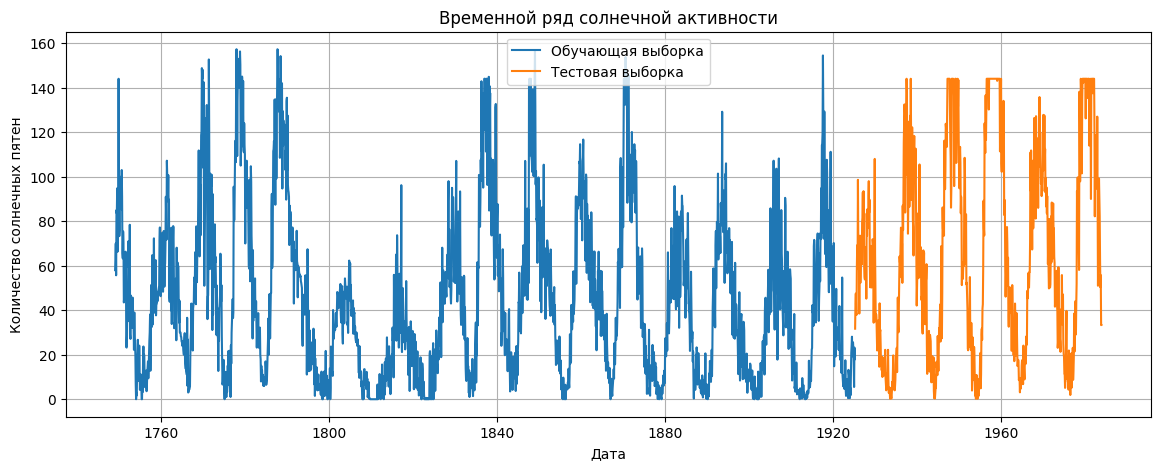

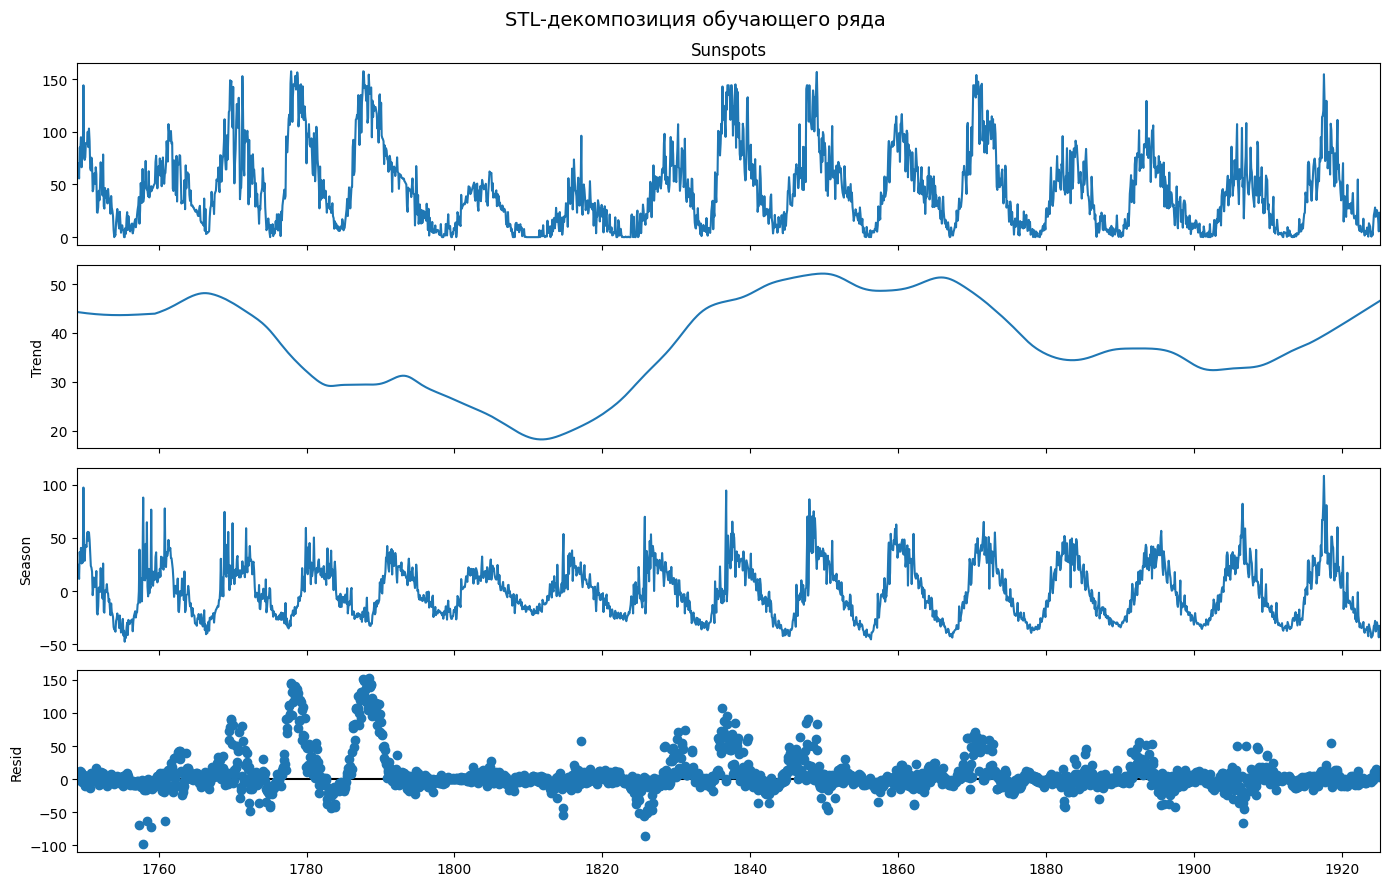

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(series.index, series, label='Обучающая выборка')
plt.plot(test_series.index, test_series, label='Тестовая выборка')

plt.title('Временной ряд солнечной активности')
plt.xlabel('Дата')
plt.ylabel('Количество солнечных пятен')
plt.legend()
plt.grid(True)
plt.show()


stl = STL(series, period=132, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 9)
fig.suptitle('STL-декомпозиция обучающего ряда', fontsize=14)
plt.tight_layout()
plt.show()

## Модель ExponentialSmoothing

На основе визуального анализа и STL-декомпозиции можно сделать вывод, что временной ряд солнечной активности имеет выраженную циклическую структуру. Основной цикл солнечной активности составляет примерно 11 лет.

Для модели `ExponentialSmoothing` выберем следующие параметры:

- `trend='add'` — аддитивный тренд;
- `seasonal='add'` — аддитивная сезонность;
- `seasonal_periods=132` — период сезонности в месяцах;
- `damped_trend=True` — сглаживание тренда, чтобы прогноз не уходил слишком резко вверх или вниз.

c:\Users\motyn\Desktop\repositories\_OMSTU\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


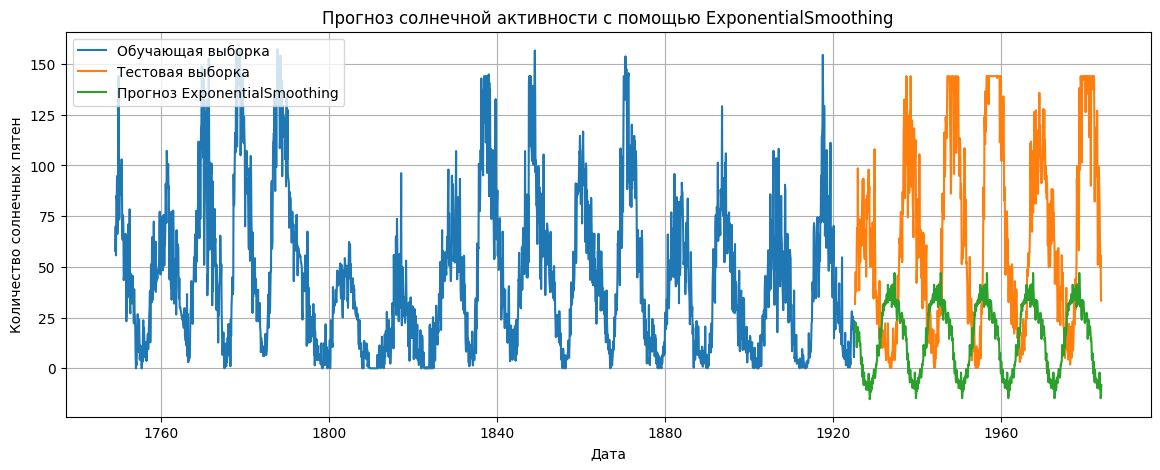

MAE: 61.267
RMSE: 73.811


In [6]:
seasonal_period = 132
forecast_steps = len(test_series)

es_model = ExponentialSmoothing(
    series,
    trend='add',
    damped_trend=True,
    seasonal='add',
    seasonal_periods=seasonal_period,
    initialization_method='estimated'
)

es_result = es_model.fit(optimized=True)

es_forecast = es_result.forecast(forecast_steps)
es_forecast.index = test_series.index

mae = mean_absolute_error(test_series, es_forecast)
rmse = np.sqrt(mean_squared_error(test_series, es_forecast))

plt.figure(figsize=(14, 5))
plt.plot(series.index, series, label='Обучающая выборка')
plt.plot(test_series.index, test_series, label='Тестовая выборка')
plt.plot(es_forecast.index, es_forecast, label='Прогноз ExponentialSmoothing')

plt.title('Прогноз солнечной активности с помощью ExponentialSmoothing')
plt.xlabel('Дата')
plt.ylabel('Количество солнечных пятен')
plt.legend()
plt.grid(True)
plt.show()

print(f'MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')

## Расширенный подбор параметров ExponentialSmoothing

В предыдущем варианте модель использовала фиксированные параметры:

- `trend='add'`
- `seasonal='add'`
- `seasonal_periods=132`
- `damped_trend=True`

Однако прогноз заметно занижал пики солнечной активности. Поэтому для улучшения результата выполним расширенный перебор параметров модели `ExponentialSmoothing` и выберем лучшую конфигурацию по RMSE на тестовой выборке.

В переборе будем изменять:

- наличие тренда: `None`, `'add'`;
- наличие затухающего тренда: `False`, `True`;
- наличие сезонности: `None`, `'add'`;
- длину сезонного периода: `120`, `132`, `144`.

Период `132` соответствует приблизительно 11-летнему циклу солнечной активности при месячных данных:

$$11 \cdot 12 = 132$$

Дополнительно проверяются соседние значения `120` и `144`, чтобы учесть возможное отклонение фактической длины цикла.

Мультипликативную сезонность не используем, так как после предварительной обработки ряд не содержит отрицательных значений, однако в нём присутствуют значения, близкие к нулю. При таких данных мультипликативная сезонность может работать нестабильно, поэтому для модели выбран более устойчивый вариант с аддитивной сезонностью.

In [7]:
forecast_steps = len(test_series)

trend_options = [None, 'add']
seasonal_options = [None, 'add']
seasonal_period_options = [120, 132, 144]

results = []

for trend in trend_options:
    for seasonal in seasonal_options:
        for seasonal_period in seasonal_period_options:
            for damped_trend in [False, True]:

                if trend is None and damped_trend:
                    continue

                if seasonal is None:
                    seasonal_periods = None
                else:
                    seasonal_periods = seasonal_period

                model = ExponentialSmoothing(
                    series,
                    trend=trend,
                    damped_trend=damped_trend,
                    seasonal=seasonal,
                    seasonal_periods=seasonal_periods,
                    initialization_method='estimated'
                )

                fitted_model = model.fit(optimized=True)

                forecast = fitted_model.forecast(forecast_steps)
                forecast.index = test_series.index
                forecast = forecast.clip(lower=0)

                mae = mean_absolute_error(test_series, forecast)
                rmse = np.sqrt(mean_squared_error(test_series, forecast))

                results.append({
                    'trend': trend,
                    'damped_trend': damped_trend,
                    'seasonal': seasonal,
                    'seasonal_periods': seasonal_periods,
                    'MAE': mae,
                    'RMSE': rmse,
                    'model': fitted_model,
                    'forecast': forecast
                })

results_df = pd.DataFrame(results).drop(columns=['model', 'forecast'])
results_df = results_df.sort_values('RMSE').reset_index(drop=True)

display(results_df)

best_result = min(results, key=lambda x: x['RMSE'])

es_result = best_result['model']
es_forecast = best_result['forecast']

print('Лучшие параметры модели:')
print(f"trend: {best_result['trend']}")
print(f"damped_trend: {best_result['damped_trend']}")
print(f"seasonal: {best_result['seasonal']}")
print(f"seasonal_periods: {best_result['seasonal_periods']}")
print(f"MAE: {best_result['MAE']:.3f}")
print(f"RMSE: {best_result['RMSE']:.3f}")

c:\Users\motyn\Desktop\repositories\_OMSTU\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\motyn\Desktop\repositories\_OMSTU\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\motyn\Desktop\repositories\_OMSTU\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\motyn\Desktop\repositories\_OMSTU\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\motyn\Desktop\repositories\_OMSTU\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\m

,trend,damped_trend,seasonal,seasonal_periods,MAE,RMSE
0,add,True,add,120.0,29.401607,35.865204
1,NaN,False,add,120.0,30.906770,39.628606
2,add,False,add,120.0,50.707153,64.338514
3,NaN,False,NaN,NaN,52.802673,67.901877
4,NaN,False,NaN,NaN,52.802673,67.901877
5,NaN,False,NaN,NaN,52.802673,67.901877
6,add,True,NaN,NaN,52.802694,67.901901
7,add,True,NaN,NaN,52.802694,67.901901
8,add,True,NaN,NaN,52.802694,67.901901
9,add,True,add,144.0,57.042158,70.472472


Лучшие параметры модели:
trend: add
damped_trend: True
seasonal: add
seasonal_periods: 120
MAE: 29.402
RMSE: 35.865


## Визуализация лучшего прогноза ExponentialSmoothing

После перебора параметров выбрана модель с минимальным значением RMSE на тестовой выборке.  
Построим график прогноза и сравним его с фактическими значениями тестового ряда.

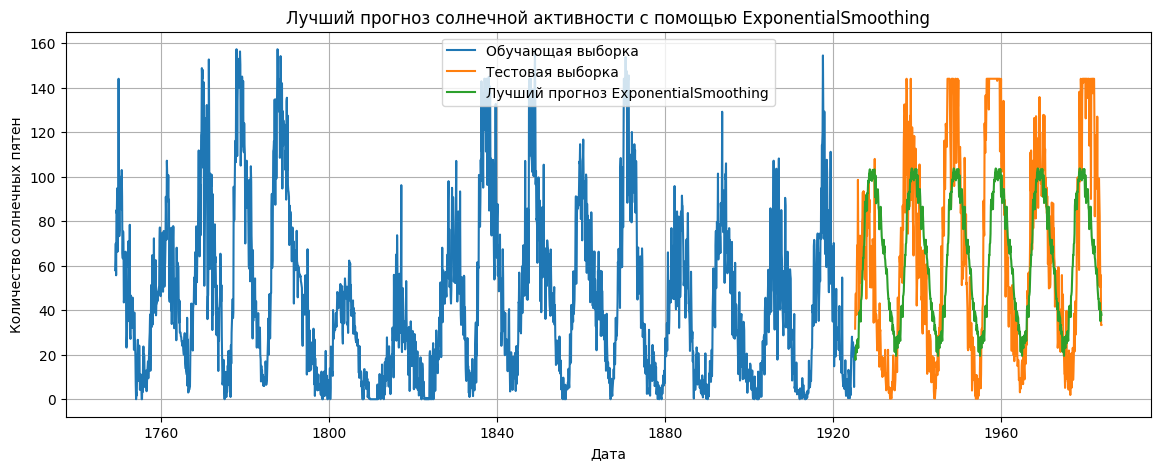

In [9]:
plt.figure(figsize=(14, 5))

plt.plot(series.index, series, label='Обучающая выборка')
plt.plot(test_series.index, test_series, label='Тестовая выборка')
plt.plot(es_forecast.index, es_forecast, label='Лучший прогноз ExponentialSmoothing')

plt.title('Лучший прогноз солнечной активности с помощью ExponentialSmoothing')
plt.xlabel('Дата')
plt.ylabel('Количество солнечных пятен')
plt.legend()
plt.grid(True)
plt.show()

### Вывод по модели ExponentialSmoothing

После первичного построения модели `ExponentialSmoothing` прогноз оказался недостаточно точным: модель улавливала общий циклический характер ряда, но заметно занижала пики солнечной активности.

Для улучшения качества прогноза был выполнен расширенный перебор параметров модели. Лучший результат был получен при следующих параметрах:

- `trend='add'`
- `damped_trend=True`
- `seasonal='add'`
- `seasonal_periods=120`

Полученные значения метрик:

- `MAE = 29.402`
- `RMSE = 35.865`

По сравнению с первоначальной моделью качество прогноза заметно улучшилось: значение RMSE снизилось примерно с `73.811` до `35.865`. Это означает, что расширенный подбор параметров позволил существенно уменьшить среднюю ошибку прогноза.

На графике видно, что модель стала лучше воспроизводить циклическую структуру ряда и амплитуду колебаний солнечной активности. При этом прогноз всё ещё не полностью совпадает с фактическими значениями тестовой выборки: отдельные пики и резкие изменения ряда сглаживаются. Это связано с тем, что `ExponentialSmoothing` хорошо описывает регулярные трендовые и сезонные компоненты, но хуже учитывает резкие всплески и нестабильность амплитуды.

Таким образом, лучшая модель `ExponentialSmoothing` может использоваться для базового прогноза солнечной активности, однако в ошибках прогноза может сохраняться зависимость и изменчивая дисперсия. Поэтому далее необходимо проанализировать квадраты остатков и их автокорреляцию.

## Анализ квадратов остатков

После построения лучшего прогноза рассчитаем остатки модели как разницу между предсказанными и истинными значениями:

$$e_t = \hat{y}_t - y_t$$

Затем вычислим квадраты остатков:

$$e_t^2 = (\hat{y}_t - y_t)^2$$

Квадраты остатков нужны для анализа изменчивости ошибок. Если на графике автокорреляции квадратов остатков есть значимые пики, выходящие за границы доверительного интервала, это означает, что в ошибках присутствует зависимость. В таком случае можно предположить наличие кластеризации волатильности, и применение модели GARCH становится обоснованным.

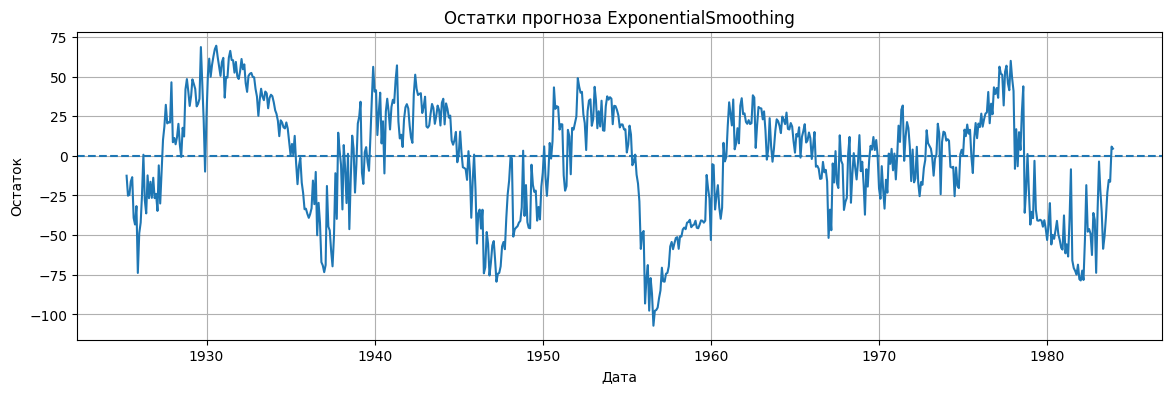

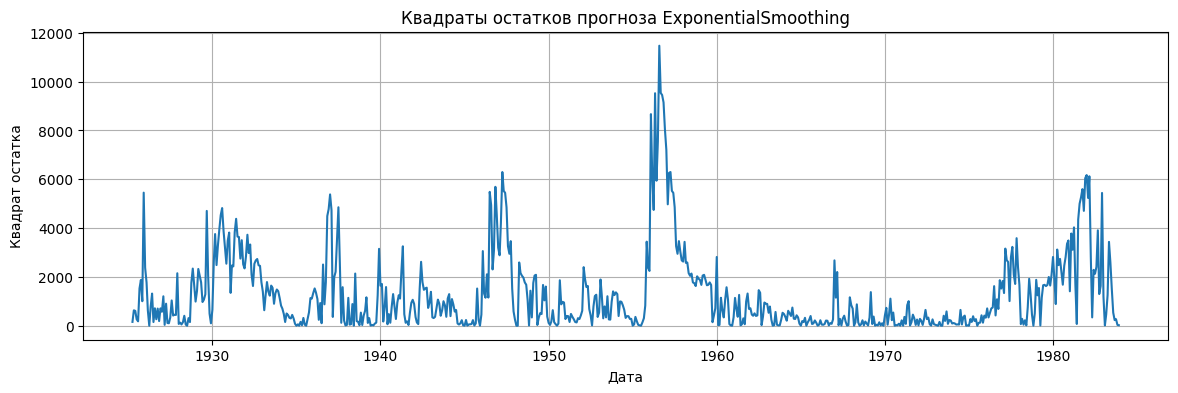

<Figure size 1400x500 with 0 Axes>

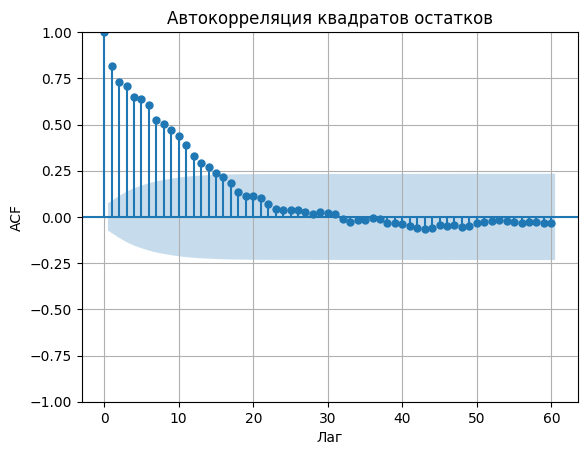

In [10]:
residuals = es_forecast - test_series
squared_residuals = residuals ** 2

plt.figure(figsize=(14, 4))
plt.plot(residuals.index, residuals)
plt.axhline(0, linestyle='--')

plt.title('Остатки прогноза ExponentialSmoothing')
plt.xlabel('Дата')
plt.ylabel('Остаток')
plt.grid(True)
plt.show()


plt.figure(figsize=(14, 4))
plt.plot(squared_residuals.index, squared_residuals)

plt.title('Квадраты остатков прогноза ExponentialSmoothing')
plt.xlabel('Дата')
plt.ylabel('Квадрат остатка')
plt.grid(True)
plt.show()


plt.figure(figsize=(14, 5))
plot_acf(squared_residuals.dropna(), lags=60)

plt.title('Автокорреляция квадратов остатков')
plt.xlabel('Лаг')
plt.ylabel('ACF')
plt.grid(True)
plt.show()

### Вывод по анализу квадратов остатков

На графике остатков видно, что ошибки прогноза распределены неравномерно во времени: есть периоды с небольшими отклонениями и периоды с крупными ошибками. Это говорит о том, что изменчивость ошибок не является постоянной.

График квадратов остатков показывает выраженные всплески. Особенно заметны периоды, когда квадраты ошибок резко возрастают. Такие участки можно интерпретировать как периоды повышенной волатильности.

На графике автокорреляции квадратов остатков наблюдаются значимые положительные автокорреляции на первых лагах. Несколько первых значений ACF выходят за границы доверительного интервала, а затем автокорреляция постепенно убывает.

Это означает, что в квадратах остатков присутствует зависимость: большие ошибки склонны группироваться во времени. Следовательно, ошибки модели имеют изменяющуюся во времени дисперсию. Такое поведение соответствует идее кластеризации волатильности и делает применение модели GARCH(1,1) обоснованным.

## Модель GARCH(1,1)

После анализа квадратов остатков была обнаружена зависимость в ошибках прогноза.  
Для моделирования изменяющейся во времени дисперсии построим модель `GARCH(1,1)`.

Модель `GARCH(1,1)` описывает условную дисперсию ряда через прошлые квадраты ошибок и прошлые значения самой дисперсии:

$$\sigma_t^2 = \omega + \alpha_1 e_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

где:

- $\sigma_t^2$ — условная дисперсия в момент времени $t$;
- $e_{t-1}^2$ — квадрат ошибки на предыдущем шаге;
- $\sigma_{t-1}^2$ — условная дисперсия на предыдущем шаге;
- $\omega$, $\alpha_1$, $\beta_1$ — параметры модели.

In [11]:
garch_data = residuals.dropna() * 10

garch_model = arch_model(
    garch_data,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1,
    rescale=False
)

garch_result = garch_model.fit(disp='off')

print(garch_result.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -5001.30
Distribution:                  Normal   AIC:                           10008.6
Method:            Maximum Likelihood   BIC:                           10022.3
                                        No. Observations:                  705
Date:                 Ср, май 20 2026   Df Residuals:                      705
Time:                        02:05:56   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega       9551.5344   5536.464      1.725  8.449e-02 

## Прогноз волатильности с помощью GARCH(1,1)

Для построения прогноза волатильности используем остатки модели `ExponentialSmoothing` на обучающей выборке.  
После этого обучим модель `GARCH(1,1)` и построим прогноз условной волатильности на период тестовой выборки.

Такой подход корректнее, чем обучение GARCH на тестовых остатках, потому что тестовая выборка должна использоваться для проверки и визуализации результата, а не для подгонки параметров модели.

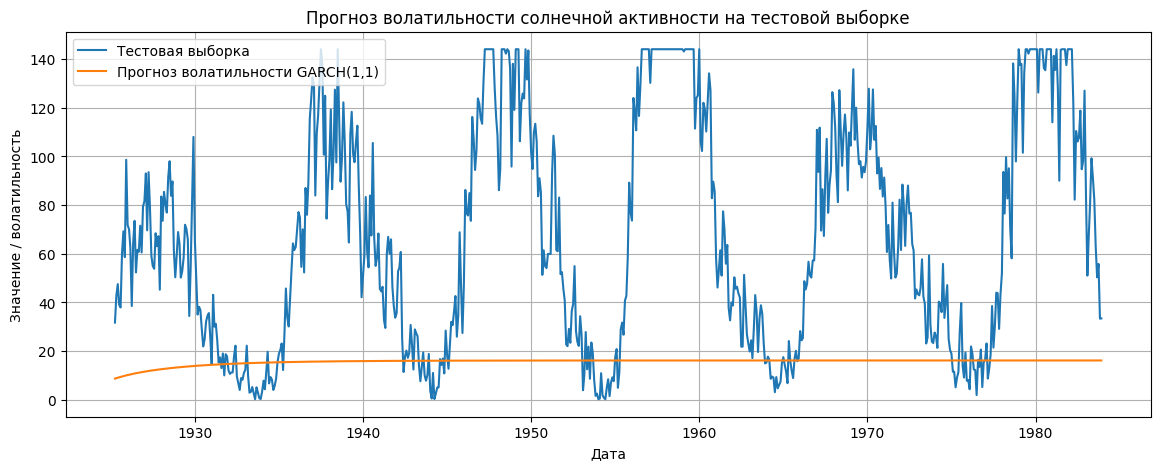

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -13263.8
Distribution:                  Normal   AIC:                           26533.5
Method:            Maximum Likelihood   BIC:                           26550.5
                                        No. Observations:                 2115
Date:                 Ср, май 20 2026   Df Residuals:                     2115
Time:                        02:07:34   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega        457.0565    115.730      3.949  7.837e-05 [2.

In [12]:
train_fitted = es_result.fittedvalues
train_residuals = train_fitted - series

garch_train_data = train_residuals.dropna() * 10

garch_model = arch_model(
    garch_train_data,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1,
    rescale=False
)

garch_result = garch_model.fit(disp='off')

garch_forecast = garch_result.forecast(horizon=len(test_series))

variance_forecast = garch_forecast.variance.iloc[-1]
volatility_forecast = np.sqrt(variance_forecast) / 10
volatility_forecast.index = test_series.index

plt.figure(figsize=(14, 5))
plt.plot(test_series.index, test_series, label='Тестовая выборка')
plt.plot(volatility_forecast.index, volatility_forecast, label='Прогноз волатильности GARCH(1,1)')

plt.title('Прогноз волатильности солнечной активности на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('Значение / волатильность')
plt.legend()
plt.grid(True)
plt.show()

print(garch_result.summary())

## Визуализация прогноза с учетом GARCH-волатильности

Прогноз GARCH(1,1) показывает не само значение солнечной активности, а ожидаемую изменчивость ошибок модели.  
Поэтому для наглядности построим прогноз `ExponentialSmoothing` вместе с интервалом, ширина которого определяется прогнозной волатильностью GARCH.

В качестве границ используем:

$$\hat{y}_t \pm 2\sigma_t$$

где:

- $\hat{y}_t$ — прогноз модели `ExponentialSmoothing`;
- $\sigma_t$ — прогнозная волатильность по модели `GARCH(1,1)`.

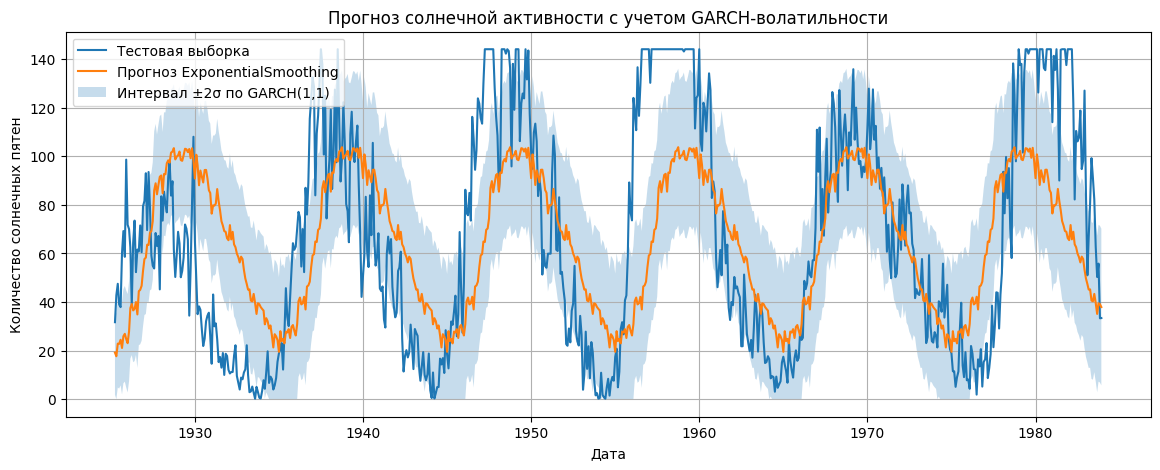

In [13]:
upper_bound = es_forecast + 2 * volatility_forecast
lower_bound = es_forecast - 2 * volatility_forecast
lower_bound = lower_bound.clip(lower=0)

plt.figure(figsize=(14, 5))

plt.plot(test_series.index, test_series, label='Тестовая выборка')
plt.plot(es_forecast.index, es_forecast, label='Прогноз ExponentialSmoothing')
plt.fill_between(
    test_series.index,
    lower_bound,
    upper_bound,
    alpha=0.25,
    label='Интервал ±2σ по GARCH(1,1)'
)

plt.title('Прогноз солнечной активности с учетом GARCH-волатильности')
plt.xlabel('Дата')
plt.ylabel('Количество солнечных пятен')
plt.legend()
plt.grid(True)
plt.show()

### Вывод по прогнозу с учетом GARCH-волатильности

На графике представлен прогноз солнечной активности, полученный моделью `ExponentialSmoothing`, а также интервал неопределённости, построенный на основе прогнозной волатильности модели `GARCH(1,1)`.

Модель `ExponentialSmoothing` хорошо воспроизводит общий циклический характер ряда, однако не всегда точно попадает в резкие пики и минимумы солнечной активности. Это связано с тем, что ряд имеет нестабильную амплитуду колебаний, а отдельные всплески трудно описать только с помощью тренда и сезонной компоненты.

Модель `GARCH(1,1)` была использована не для прогноза самих значений солнечной активности, а для оценки изменчивости ошибок прогноза. Интервал вида

$$\hat{y}_t \pm 2\sigma_t$$

показывает область возможных отклонений прогноза от фактических значений.

По графику видно, что значительная часть фактических значений тестовой выборки попадает внутрь построенного интервала. При этом отдельные резкие пики всё равно выходят за его границы, что говорит о высокой нестабильности ряда и сложности точного прогнозирования экстремальных значений.

Таким образом, совместное использование `ExponentialSmoothing` и `GARCH(1,1)` позволяет не только построить прогноз солнечной активности, но и оценить неопределённость этого прогноза через изменяющуюся во времени волатильность ошибок.